In [82]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [92]:
class Value:

    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None #叶节点
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')

        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward = _backward

        return out

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward

        return out
    
    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only supporting int/float powers for now"
        out = Value(self.data**other, (self, ), f'**{other}')

        def _backward():
            self.grad += other * self.data**(other - 1) * out.grad
        out._backward = _backward

        return out
    
    def __rmul__(self, other):
        return self * other
    
    def __truediv__(self, other):
        return self * other**-1
    
    def __neg__(self):
        return self * -1
    
    def __sub__(self, other):
        return self + (-other)
    
    def __radd__(self, other):
        return self + other
    
    def __rsub__(self, other):
        return (-self) + other
    
    def relu(self):
        out = Value(0 if self.data<0 else self.data, (self, ), 'ReLu')

        def _backward():
            self.grad += (1.0 if self.data > 0 else 0.0) * out.grad
        out._backward = _backward

        return out
    
    def sigmoid(self):
        x = self.data
        s = 1.0 / (1.0 + math.exp(-x))
        out = Value(s, (self, ), 'sigmoid')

        def _backward():
            self.grad += (s * (1 - s)) * out.grad
        out._backward = _backward

        return out
    
    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self, ), 'exp')

        def _backward():
            self.grad += out.data * out.grad
        out._backward = _backward

        return out
    
    def log(self):
        out = Value(math.log(self.data), (self, ), 'log')

        def _backward():
            self.grad += (1.0 / self.data) * out.grad
        out._backward = _backward

        return out
    
    def backward(self):

        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        self.grad = 1.0
        for node in reversed(topo):
            node._backward()
    
    def zero_grad(self):
        """递归清零自身及所有上游节点的梯度"""
        self.grad = 0.0
        for child in self._prev:
            child.zero_grad()


In [93]:
import random

class Module:
    def zero_grad(self):
        for p in self.parameters():
            p.grad = 0.0

    def parameters(self):
        return []
    
class Neuron(Module):
    
    def __init__(self, min, activation='relu'):
        self.w = [Value(random.uniform(-1, 1)) for _ in range(min)]
        self.b = Value(random.uniform(-1, 1))
        self.activation = activation

    def __call__(self, x):
        act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
        if self.activation == 'relu':
            return act.relu()
        elif self.activation == 'tanh':
            return act.tanh()
        elif self.activation == 'sigmoid':
            return act.sigmoid()
        else:
            return act
    
    def parameters(self):
        return self.w + [self.b]
    
class Layer(Module):

    def __init__(self, min, nout, activation = 'relu'):
        self.neurons = [Neuron(min, activation) for _ in range(nout)]

    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs
    
    def parameters(self):
       return [p for neuron in self.neurons for p in neuron.parameters()]
    
class MLP(Module):

    def __init__(self, min, nouts):
        sz = [min] + nouts
        self.layers = []
        for i in range(len(nouts)):
            is_last = (i == len(nouts) - 1)
            act = 'sigmoid' if is_last else 'relu'
            self.layers.append(Layer(sz[i], sz[i+1], activation = act))

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x
    
    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]
    

    
class Linear(Module):
    def __init__(self, min, nout):
        self.W = [[Value(random.uniform(-1, 1)) for _ in range(min)] for _ in range(nout)]
        self.b = [Value(random.uniform(-1, 1)) for _ in range(nout)]
    
    def __call__(self, x):
        return [sum((w * xi for w, xi in zip(row, x)), b) for row, b in zip(self.W, self.b)]
    
    def parameters(self):
        return [p for row in self.W for p in row] + self.b


In [94]:
# ============================================================
# 测试数据：手写二分类，正负混合
# 目标: 判断 (x1, x2) 是否在对角线上方 → 标签 1，否则 0
# 故意选含正负数的样本
# ============================================================
xs = [
    [ 2.0,  3.0],   # 明显上方 → 1
    [-3.0, -2.0],   # 明显下方 → 0
    [ 0.5, -1.0],   # 边界 → 0
    [-1.0,  0.5],   # 边界 → 1
    [ 1.0,  1.0],   # 上方 → 1
    [-2.0,  1.0],   # 上方 → 1
    [ 3.0, -2.0],   # 下方 → 0
    [-1.5, -1.5],   # 下方 → 0
]
ys = [1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0]

print("样本数:", len(xs))
for i, (x, y) in enumerate(zip(xs, ys)):
    print(f"  {i}: x={x}  →  y={y:.0f}")

样本数: 8
  0: x=[2.0, 3.0]  →  y=1
  1: x=[-3.0, -2.0]  →  y=0
  2: x=[0.5, -1.0]  →  y=0
  3: x=[-1.0, 0.5]  →  y=1
  4: x=[1.0, 1.0]  →  y=1
  5: x=[-2.0, 1.0]  →  y=1
  6: x=[3.0, -2.0]  →  y=0
  7: x=[-1.5, -1.5]  →  y=0


In [95]:
# ============================================================
# 新建 MLP(2输入, [8,8,1]) + 训练
# 关键: zero_grad() 在循环里面每一轮都调用
# ============================================================
import random
random.seed(42)

n = MLP(2, [8, 8, 1])
lr = 0.05
epochs = 100

print("初始预测:")
for i, x in enumerate(xs):
    pred = n(x)
    print(f"  样本{i}: pred={pred.data:.4f}  target={ys[i]}")

print(f"\n训练 {epochs} 轮 (lr={lr}):")
for k in range(epochs):
    # ★ zero_grad 必须在循环内
    n.zero_grad()

    # forward
    ypred = [n(x) for x in xs]
    loss = sum(-(ygt * yout.log() + (1 - ygt) * (1 - yout).log())
               for ygt, yout in zip(ys, ypred))

    # backward
    loss.backward()

    # update
    for p in n.parameters():
        p.data += -lr * p.grad

    if k % 20 == 0:
        preds_str = "  ".join(f"{n(x).data:+.4f}" for x in xs)
        print(f"  epoch {k:3d}: loss={loss.data:.6f}  preds=[{preds_str}]")

# 最终结果
print("\n最终结果:")
correct = 0
for i, x in enumerate(xs):
    pred = n(x)
    pred_label = 1 if pred.data > 0.5 else 0
    ok = pred_label == ys[i]
    correct += ok
    print(f"  样本{i}: pred={pred.data:+.4f} → {pred_label}  target={ys[i]}  {'PASS' if ok else 'FAIL'}")
print(f"\n准确率: {correct}/{len(xs)}  ({100*correct/len(xs):.1f}%)")

初始预测:
  样本0: pred=0.4434  target=1.0
  样本1: pred=0.0227  target=0.0
  样本2: pred=0.8724  target=0.0
  样本3: pred=0.2315  target=1.0
  样本4: pred=0.4898  target=1.0
  样本5: pred=0.1015  target=1.0
  样本6: pred=0.9938  target=0.0
  样本7: pred=0.2195  target=0.0

训练 100 轮 (lr=0.05):
  epoch   0: loss=12.687763  preds=[+0.4626  +0.0036  +0.3213  +0.3237  +0.4680  +0.1922  +0.1829  +0.0403]
  epoch  20: loss=0.336643  preds=[+0.9221  +0.0008  +0.0326  +0.9463  +0.9183  +0.9554  +0.0001  +0.0102]
  epoch  40: loss=0.116330  preds=[+0.9668  +0.0002  +0.0107  +0.9834  +0.9649  +0.9881  +0.0000  +0.0031]
  epoch  60: loss=0.065172  preds=[+0.9798  +0.0001  +0.0058  +0.9915  +0.9787  +0.9944  +0.0000  +0.0016]
  epoch  80: loss=0.043863  preds=[+0.9857  +0.0001  +0.0038  +0.9947  +0.9851  +0.9966  +0.0000  +0.0011]

最终结果:
  样本0: pred=+0.9889 → 1  target=1.0  PASS
  样本1: pred=+0.0000 → 0  target=0.0  PASS
  样本2: pred=+0.0028 → 0  target=0.0  PASS
  样本3: pred=+0.9962 → 1  target=1.0  PASS
  样本4: pred=+0

In [96]:
# ============================================================
# 梯度正确性验证: 用数值梯度 (finite difference) 对照 autograd
# ============================================================
def numerical_grad(f, x, h=1e-6):
    """对 float x 计算 f(x) 的数值导数"""
    return (f(x + h) - f(x - h)) / (2 * h)

# 测试 sigmoid
v = Value(0.3)
out = v.sigmoid()
out.backward()
num_grad = numerical_grad(lambda x: 1/(1+math.exp(-x)), 0.3)
print(f"Sigmoid 梯度检查:")
print(f"  autograd: {v.grad:.8f}")
print(f"  numerical:{num_grad:.8f}")
print(f"  diff: {abs(v.grad - num_grad):.2e}")

# 测试 log
v2 = Value(0.5)
out2 = v2.log()
out2.backward()
num_grad2 = numerical_grad(math.log, 0.5)
print(f"\nLog 梯度检查:")
print(f"  autograd: {v2.grad:.8f}")
print(f"  numerical:{num_grad2:.8f}")
print(f"  diff: {abs(v2.grad - num_grad2):.2e}")

# 测试复合: BCE 对一条样本的梯度
v3 = Value(0.7)
tgt = 1.0
out3 = -(tgt * v3.log() + (1 - tgt) * (1 - v3).log())
out3.backward()
num_grad3 = numerical_grad(lambda x: -(tgt * math.log(x) + (1 - tgt) * math.log(1 - x)), 0.7)
print(f"\nBCE 梯度检查 (p=0.7, target=1):")
print(f"  autograd: {v3.grad:.8f}")
print(f"  numerical:{num_grad3:.8f}")
print(f"  diff: {abs(v3.grad - num_grad3):.2e}")

Sigmoid 梯度检查:
  autograd: 0.24445831
  numerical:0.24445831
  diff: 1.38e-11

Log 梯度检查:
  autograd: 2.00000000
  numerical:2.00000000
  diff: 2.00e-12

BCE 梯度检查 (p=0.7, target=1):
  autograd: -1.42857143
  numerical:-1.42857143
  diff: 2.52e-11


In [97]:
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt
def draw_moon():
    X_moon, Y_moon = make_moons(n_samples=40, noise=0.8)
    plt.figure('moon')
    plt.scatter(X_moon[:,0], X_moon[:,1], s=100, marker='o', edgecolors='r', c=Y_moon)
    plt.title('data by make_moon()')

    plt.show()



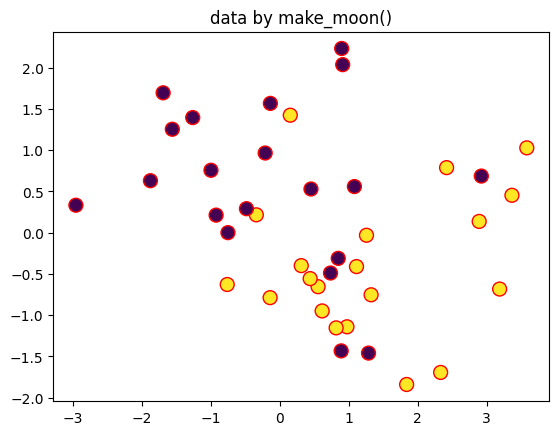

In [98]:
draw_moon()